In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium 
from folium.plugins import HeatMap
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.stats import shapiro

In [5]:
df = pd.read_csv('../data/indonesia_earthquake.csv')
df.head()

,date,time,latitude,longitude,depth,magnitude
0,2008-11-01,00:31:25,-0.60,98.89553,20.0,2.99
1,2008-11-01,01:34:29,-6.61,129.38722,30.1,5.51
2,2008-11-01,01:38:14,-3.65,127.99068,5.0,3.54
3,2008-11-01,02:20:05,-4.20,128.09700,5.0,2.42
4,2008-11-01,02:32:18,-4.09,128.20047,10.0,2.41


In [6]:
print(df.isnull().sum())

date         0
time         0
latitude     0
longitude    0
depth        0
magnitude    0
dtype: int64


In [7]:
print(df.duplicated().sum())

2679


In [8]:
df_clean = df.drop_duplicates()
print(df_clean.duplicated().sum())

0


In [9]:
df_clean.describe()

,latitude,longitude,depth,magnitude
count,84693.000000,84693.000000,84693.000000,84693.000000
mean,-3.422786,119.234150,48.482659,3.558802
std,4.340674,10.628603,76.393958,0.793656
min,-11.000000,95.002390,1.000000,1.000000
25%,-7.940000,114.034570,10.000000,2.980000
50%,-2.900000,121.193050,15.500000,3.500000
75%,0.100000,126.847530,52.300000,4.120000
max,6.000000,140.981520,750.000000,7.920000


In [10]:
sample_size = min(5000, len(df_clean))
df_sample = df_clean.sample(n=sample_size, random_state=42)

indonesia_map = folium.Map(
     location=[-2.5, 118],
     zoom_start=5,
     tiles='cartodbpositron'
)

heat_data = [[row['latitude'], row['longitude'], row['magnitude']]
             for idx, row in df_sample.iterrows()]

HeatMap(heat_data,
        min_opacity=0.3,
        radius=8,
        blur=10,
        gradient={0.4: 'blue', 0.65: 'lime', 0.8: 'orange', 1: 'red'}
).add_to(indonesia_map)

print("HEATMAP SEBARAN GEMPA BUMI DI INDONESIA")
print('='*40)
print("Warna merah = area dengan kepadatan gempa tinggi")
print("Warna biru = area dengan kepadatan gempa rendah")
indonesia_map

HEATMAP SEBARAN GEMPA BUMI DI INDONESIA
Warna merah = area dengan kepadatan gempa tinggi
Warna biru = area dengan kepadatan gempa rendah


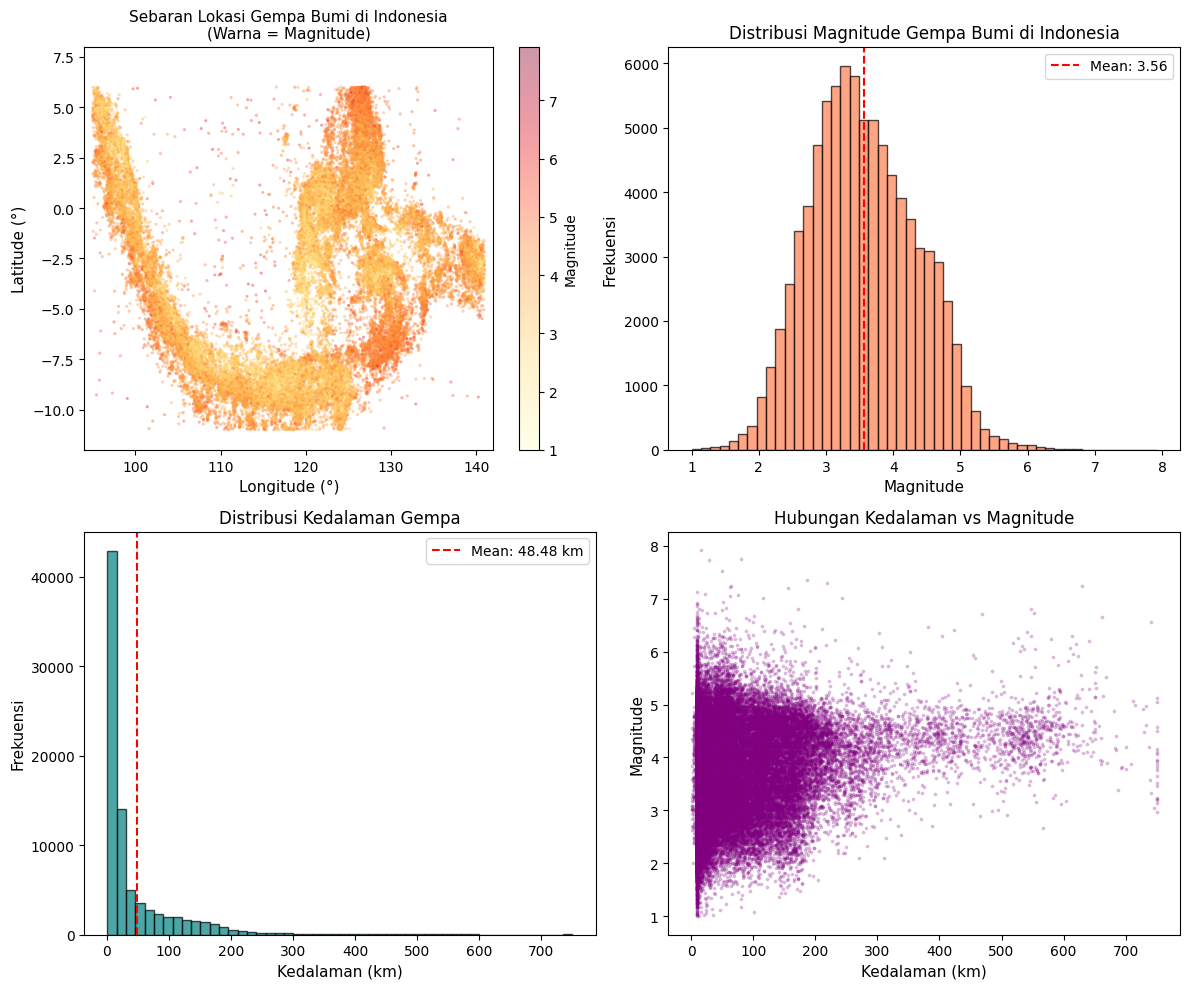

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
scatter1 = axes[0,0].scatter(df_clean['longitude'], df_clean['latitude'],
                             c=df_clean['magnitude'], cmap='YlOrRd', alpha=0.4, s=5, edgecolors='none')
axes[0, 0].set_xlabel('Longitude (°)', fontsize=11)
axes[0, 0].set_ylabel('Latitude (°)', fontsize=11)
axes[0, 0].set_title('Sebaran Lokasi Gempa Bumi di Indonesia\n(Warna = Magnitude)', fontsize=11)
plt.colorbar(scatter1, ax=axes[0, 0], label='Magnitude')
axes[0, 0].set_xlim([94, 142])
axes[0, 0].set_ylim([-12, 8])

axes[0, 1].hist(df_clean['magnitude'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Magnitude', fontsize=11)
axes[0, 1].set_ylabel('Frekuensi', fontsize=11)
axes[0, 1].set_title('Distribusi Magnitude Gempa Bumi di Indonesia', fontsize=12)
axes[0, 1].axvline(df_clean['magnitude'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean['magnitude'].mean():.2f}')
axes[0, 1].legend()

axes[1, 0].hist(df_clean['depth'], bins=50, color='teal', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Kedalaman (km)', fontsize=11)
axes[1, 0].set_ylabel('Frekuensi', fontsize=11)
axes[1, 0].set_title('Distribusi Kedalaman Gempa', fontsize=12)
axes[1, 0].axvline(df_clean['depth'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {df_clean["depth"].mean():.2f} km')
axes[1, 0].legend()

axes[1, 1].scatter(df_clean['depth'], df_clean['magnitude'], alpha=0.2, s=3, color='purple')
axes[1, 1].set_xlabel('Kedalaman (km)', fontsize=11)
axes[1, 1].set_ylabel('Magnitude', fontsize=11)
axes[1, 1].set_title('Hubungan Kedalaman vs Magnitude', fontsize=12)

plt.tight_layout()
plt.show()

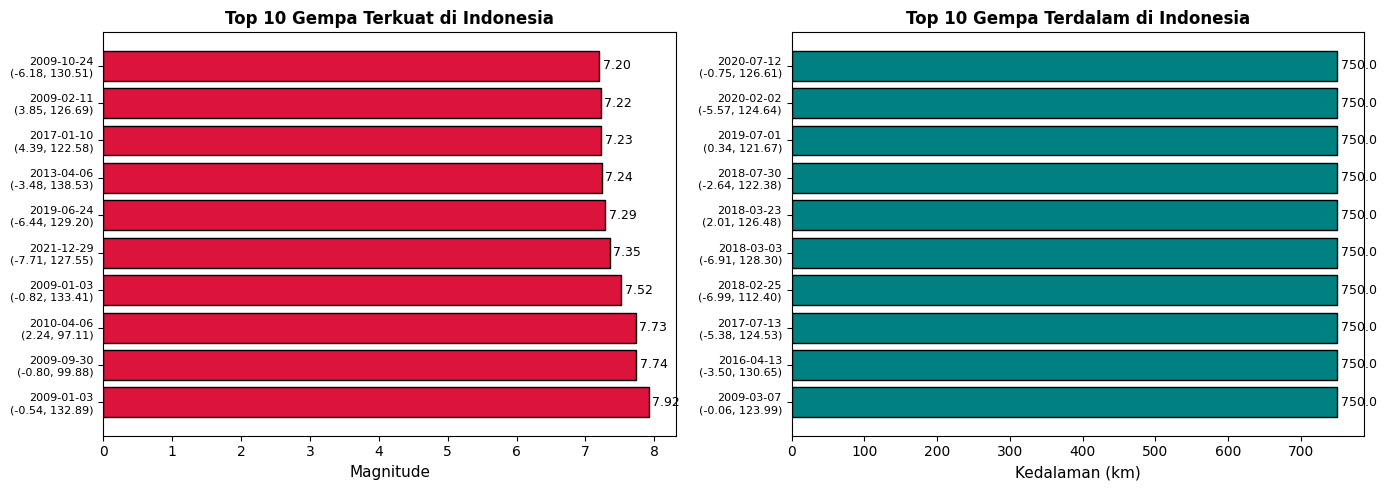

   Gempa terkuat: Magnitude 7.92
   Gempa terdalam: 750.0 km


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_magnitude = df_clean.nlargest(10, 'magnitude')[['date', 'latitude', 'longitude', 'magnitude', 'depth']]
axes[0].barh(range(10), top_magnitude['magnitude'], color='crimson', edgecolor='black')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([f"{row['date']}\n({row['latitude']:.2f}, {row['longitude']:.2f})" 
                         for _, row in top_magnitude.iterrows()], fontsize=8)
axes[0].set_xlabel('Magnitude', fontsize=11)
axes[0].set_title('Top 10 Gempa Terkuat di Indonesia', fontsize=12, fontweight='bold')
for i, v in enumerate(top_magnitude['magnitude']):
    axes[0].text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=9)

top_depth = df_clean.nlargest(10, 'depth')[['date', 'latitude', 'longitude', 'magnitude', 'depth']]
axes[1].barh(range(10), top_depth['depth'], color='teal', edgecolor='black')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([f"{row['date']}\n({row['latitude']:.2f}, {row['longitude']:.2f})" 
                         for _, row in top_depth.iterrows()], fontsize=8)
axes[1].set_xlabel('Kedalaman (km)', fontsize=11)
axes[1].set_title('Top 10 Gempa Terdalam di Indonesia', fontsize=12, fontweight='bold')
for i, v in enumerate(top_depth['depth']):
    axes[1].text(v + 5, i, f'{v:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"   Gempa terkuat: Magnitude {df_clean['magnitude'].max():.2f}")
print(f"   Gempa terdalam: {df_clean['depth'].max():.1f} km")

In [13]:
numeric_cols = ['latitude', 'longitude', 'depth', 'magnitude']
normalityTest_df = df_clean[numeric_cols]

print("UJI NORMALITAS (SHAPIRO-WILK)")
print("="*70)
print("H0: Data berdistribusi normal")
print("H1: Data tidak berdistribusi normal")
print("α = 0.05\n")

sample_for_test = normalityTest_df.sample(n=min(5000, len(normalityTest_df)), random_state=42)

results_normality = []
for col in numeric_cols:
    stat, p_value = shapiro(sample_for_test[col])
    is_normal = "Normal" if p_value > 0.05 else "Tidak Normal"
    results_normality.append({
        'Kolom': col,
        'Statistic': stat,
        'P-Value': p_value,
        'Keputusan': is_normal
    })
    print(f"{col}:")
    print(f"  Statistic = {stat:.6f}, P-Value = {p_value:.6f}")
    print(f"  Keputusan: {is_normal}\n")


UJI NORMALITAS (SHAPIRO-WILK)
H0: Data berdistribusi normal
H1: Data tidak berdistribusi normal
α = 0.05

latitude:
  Statistic = 0.947069, P-Value = 0.000000
  Keputusan: Tidak Normal

longitude:
  Statistic = 0.945487, P-Value = 0.000000
  Keputusan: Tidak Normal

depth:
  Statistic = 0.542388, P-Value = 0.000000
  Keputusan: Tidak Normal

magnitude:
  Statistic = 0.994684, P-Value = 0.000000
  Keputusan: Tidak Normal



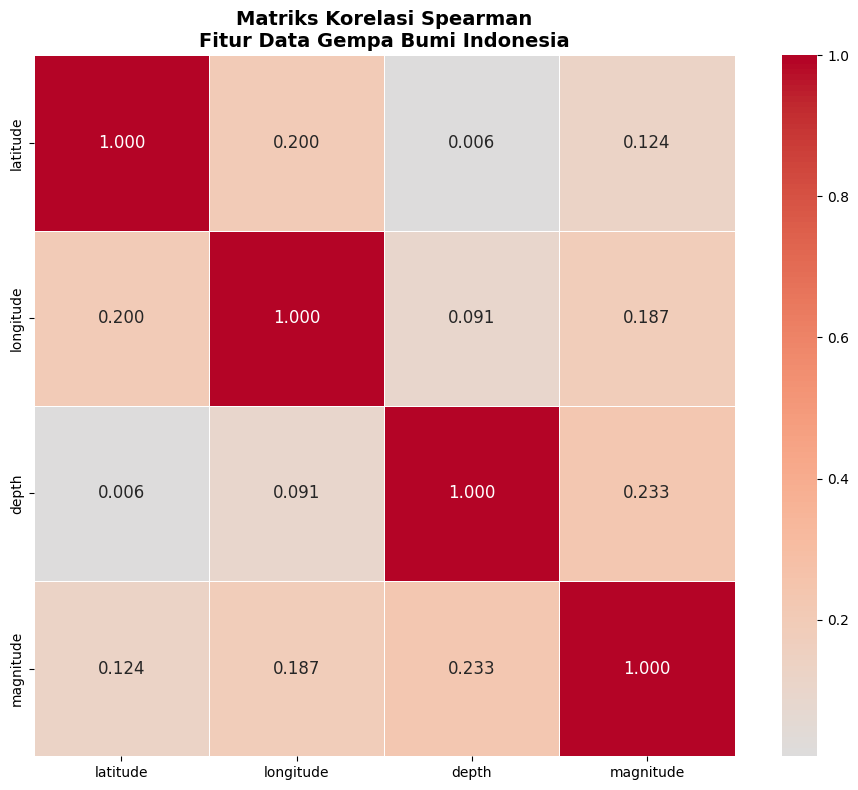

In [14]:
correlation_matrix = normalityTest_df.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.3f', linewidths=0.5, square=True,
            annot_kws={'size': 12})
plt.title('Matriks Korelasi Spearman\nFitur Data Gempa Bumi Indonesia', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

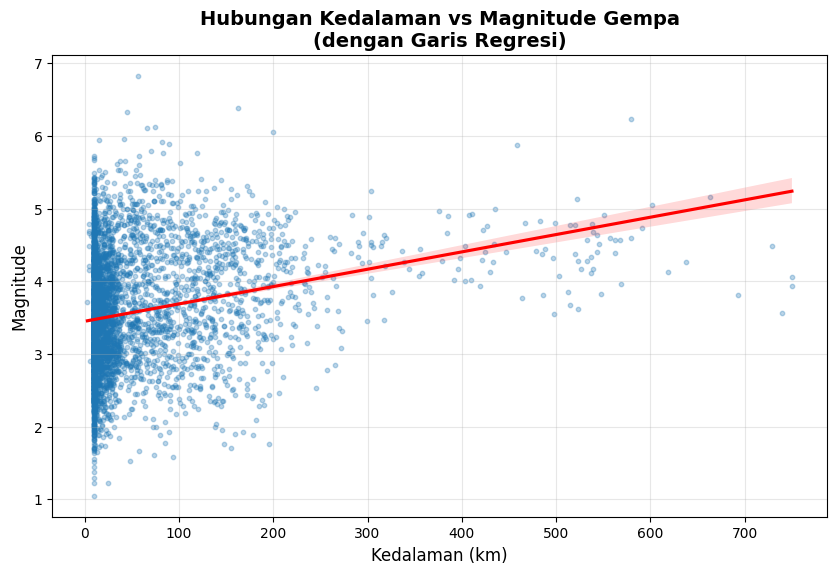


Korelasi Spearman (Depth vs Magnitude): 0.2325


In [15]:
plt.figure(figsize=(10, 6))
sns.regplot(x='depth', y='magnitude', data=df_clean.sample(5000, random_state=42),
            scatter_kws={'alpha': 0.3, 's': 10}, line_kws={'color': 'red'})
plt.xlabel('Kedalaman (km)', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)
plt.title('Hubungan Kedalaman vs Magnitude Gempa\n(dengan Garis Regresi)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

corr_depth_mag = df_clean['depth'].corr(df_clean['magnitude'], method='spearman')
print(f"\nKorelasi Spearman (Depth vs Magnitude): {corr_depth_mag:.4f}")

In [16]:
features = ['latitude', 'longitude', 'depth', 'magnitude']
X = df_clean[features].copy()

print("DATA SEBELUM NORMALISASI")
print("="*70)
print(X.describe())

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=X.index)

print("\n" + "="*70)
print("DATA SETELAH NORMALISASI (RobustScaler)")
print("="*70)
print(X_scaled_df.describe())

DATA SEBELUM NORMALISASI
           latitude     longitude         depth     magnitude
count  84693.000000  84693.000000  84693.000000  84693.000000
mean      -3.422786    119.234150     48.482659      3.558802
std        4.340674     10.628603     76.393958      0.793656
min      -11.000000     95.002390      1.000000      1.000000
25%       -7.940000    114.034570     10.000000      2.980000
50%       -2.900000    121.193050     15.500000      3.500000
75%        0.100000    126.847530     52.300000      4.120000
max        6.000000    140.981520    750.000000      7.920000

DATA SETELAH NORMALISASI (RobustScaler)
           latitude     longitude         depth     magnitude
count  84693.000000  84693.000000  84693.000000  84693.000000
mean      -0.065023     -0.152884      0.779732      0.051581
std        0.539885      0.829520      1.806004      0.696190
min       -1.007463     -2.044076     -0.342790     -2.192982
25%       -0.626866     -0.558691     -0.130024     -0.456140
50% 

In [17]:
print("="*70)
print("SAMPLE DATA SETELAH NORMALISASI")
print("="*70)
X_scaled_df.head(10)

SAMPLE DATA SETELAH NORMALISASI


,latitude,longitude,depth,magnitude
0,0.286070,-1.740232,0.106383,-0.447368
1,-0.461443,0.639522,0.345154,1.763158
2,-0.093284,0.530528,-0.248227,0.035088
3,-0.161692,0.538826,-0.248227,-0.947368
4,-0.148010,0.546901,-0.130024,-0.956140
5,-0.106965,0.483045,-0.130024,-0.491228
6,-0.123134,0.550235,-0.130024,-1.122807
7,0.421642,-1.784488,0.009456,0.307018
8,-0.169154,0.504865,-0.130024,-0.228070
9,-0.065920,0.561584,-0.130024,-1.035088


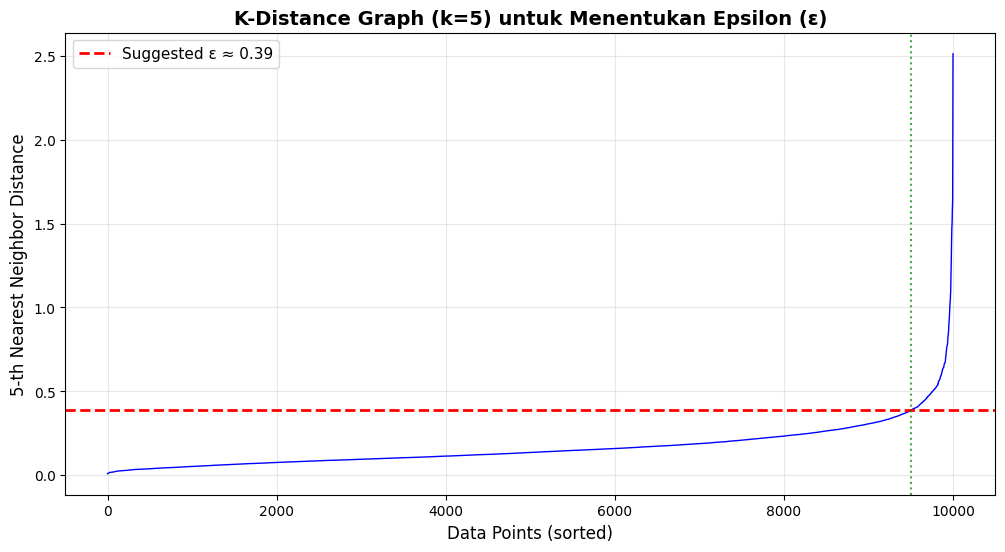


📊 Berdasarkan K-Distance Graph:
   Nilai epsilon (ε) yang disarankan: 0.39
   Nilai k (min_samples): 5


In [18]:
sample_size = min(10000, len(X_scaled))
np.random.seed(42)
sample_indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_indices]

k = 5  

neighbors = NearestNeighbors(n_neighbors=k)
neighbors.fit(X_sample)
distances, indices = neighbors.kneighbors(X_sample)

k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(12, 6))
plt.plot(k_distances, color='blue', linewidth=1)
plt.xlabel('Data Points (sorted)', fontsize=12)
plt.ylabel(f'{k}-th Nearest Neighbor Distance', fontsize=12)
plt.title(f'K-Distance Graph (k={k}) untuk Menentukan Epsilon (ε)', fontsize=14, fontweight='bold')

elbow_idx = int(len(k_distances) * 0.95)  
eps_suggested = k_distances[elbow_idx]
plt.axhline(y=eps_suggested, color='r', linestyle='--', linewidth=2, 
            label=f'Suggested ε ≈ {eps_suggested:.2f}')
plt.axvline(x=elbow_idx, color='g', linestyle=':', alpha=0.7)

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n📊 Berdasarkan K-Distance Graph:")
print(f"   Nilai epsilon (ε) yang disarankan: {eps_suggested:.2f}")
print(f"   Nilai k (min_samples): {k}")

In [19]:
eps = 0.5
min_samples = 5

dbscan_model = DBSCAN(eps=eps, min_samples=min_samples)
cluster_labels = dbscan_model.fit_predict(X_scaled)

df_clustered = df_clean.copy()
df_clustered['Cluster'] = cluster_labels

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)

print(f"\n" + "="*70)
print("HASIL CLUSTERING")
print("="*70)
print(f"Jumlah cluster yang terbentuk: {n_clusters}")
print(f"Jumlah noise/outlier (label -1): {n_noise} ({n_noise/len(cluster_labels)*100:.2f}%)")
print(f"Jumlah data dalam cluster: {len(cluster_labels) - n_noise}")

print("\n📊 Distribusi data per cluster:")
print(df_clustered['Cluster'].value_counts().sort_index())


HASIL CLUSTERING
Jumlah cluster yang terbentuk: 5
Jumlah noise/outlier (label -1): 222 (0.26%)
Jumlah data dalam cluster: 84471

📊 Distribusi data per cluster:
Cluster
-1      222
 0    84446
 1        7
 2        7
 3        7
 4        4
Name: count, dtype: int64


In [ ]:
mask = cluster_labels != -1

if sum(mask) > 1 and n_clusters > 1:
    sil_score = silhouette_score(X_scaled[mask], cluster_labels[mask])
    
    print("="*70)
    print("EVALUASI KUALITAS CLUSTERING")
    print("="*70)
    print(f"\nSilhouette Score: {sil_score:.4f}")
    
    
    if sil_score >= 0.7:
        quality = "SANGAT BAIK - Cluster terpisah dengan jelas"
    elif sil_score >= 0.5:
        quality = "CUKUP BAIK - Ada sedikit tumpang tindih"
    elif sil_score >= 0.25:
        quality = "KURANG BAIK - Cluster kurang terpisah"
    else:
        quality = "BURUK - Cluster tidak jelas"
    
    print(f"\nKualitas Clustering: {quality}")
else:
    print("⚠️ Tidak dapat menghitung Silhouette Score (kurang dari 2 cluster)")

EVALUASI KUALITAS CLUSTERING

📊 Silhouette Score: 0.5391

✅ Kualitas Clustering: CUKUP BAIK - Ada sedikit tumpang tindih


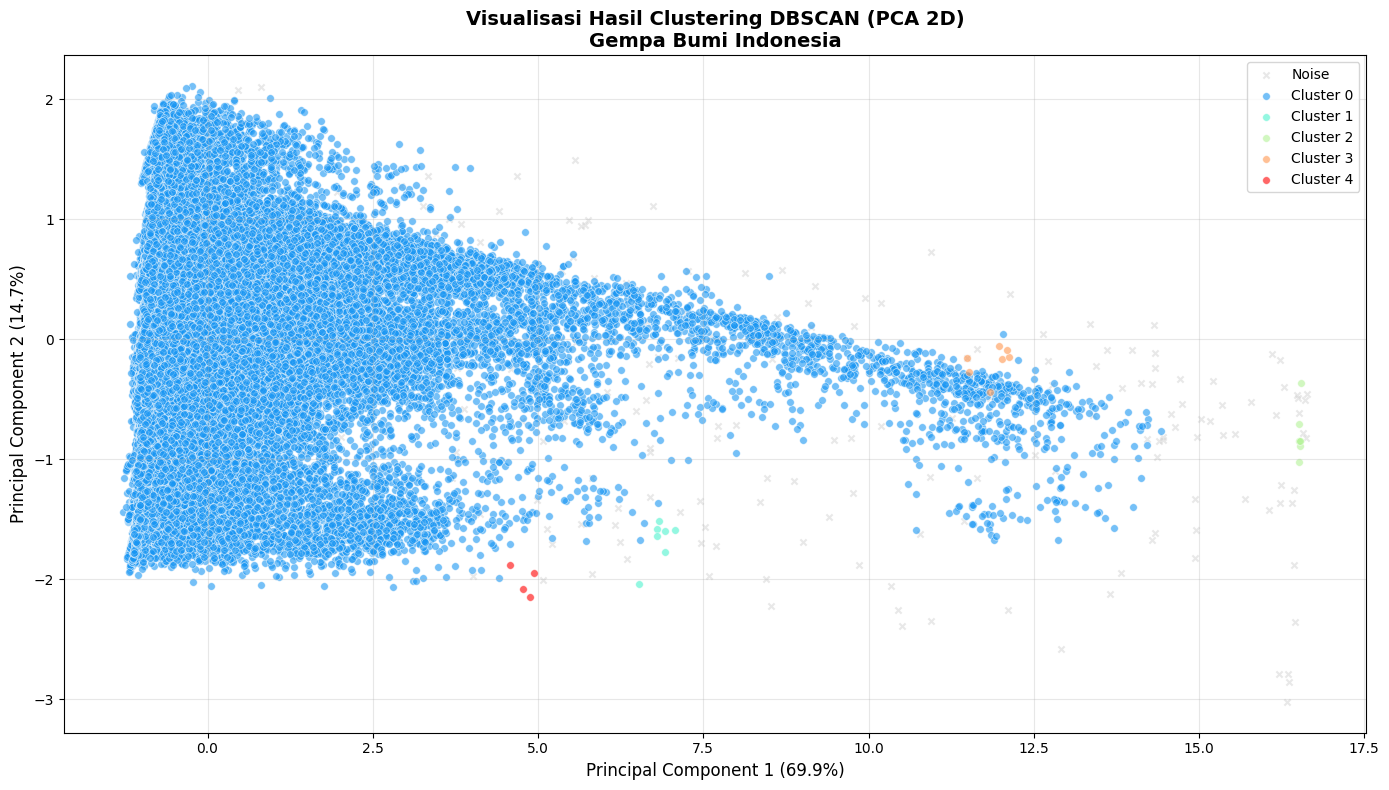


📊 Variance explained by PCA:
   PC1: 69.89%
   PC2: 14.66%
   Total: 84.55%


In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': cluster_labels
})

plt.figure(figsize=(14, 8))

unique_labels = sorted(set(cluster_labels))
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    mask = df_pca['Cluster'] == label
    if label == -1:
        plt.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                   c='lightgray', marker='x', s=20, alpha=0.5, label='Noise')
    else:
        plt.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                   c=[color], marker='o', s=30, alpha=0.6, 
                   label=f'Cluster {label}', edgecolors='white', linewidth=0.5)

plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.title('Visualisasi Hasil Clustering DBSCAN (PCA 2D)\nGempa Bumi Indonesia', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show() 

print(f"\n📊 Variance explained by PCA:")
print(f"   PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"   PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"   Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

In [ ]:
def classify_cluster(cluster_id, cluster_data, overall_data):
    """Mengklasifikasikan cluster berdasarkan karakteristik gempa"""
    avg_mag = cluster_data['magnitude'].mean()
    avg_depth = cluster_data['depth'].mean()
    overall_avg_mag = overall_data['magnitude'].mean()
    overall_avg_depth = overall_data['depth'].mean()
    
    if cluster_id == -1:
        return "Noise/Outlier"
    elif avg_mag > overall_avg_mag and avg_depth > overall_avg_depth:
        return "Gempa Dalam & Kuat"
    elif avg_mag > overall_avg_mag:
        return "Gempa Kuat"
    elif avg_depth > overall_avg_depth:
        return "Gempa Dalam"
    else:
        return "Gempa Umum"

classifications = []
for cluster_id in df_clustered['Cluster'].unique():
    cluster_data = df_clustered[df_clustered['Cluster'] == cluster_id]
    classification = classify_cluster(cluster_id, cluster_data, df_clustered)
    classifications.append({'Cluster': cluster_id, 'Klasifikasi': classification})

df_classifications = pd.DataFrame(classifications).sort_values('Cluster')
df_clustered['Klasifikasi_DBSCAN'] = df_clustered['Cluster'].map(
    dict(zip(df_classifications['Cluster'], df_classifications['Klasifikasi']))
)

print("="*70)
print("KLASIFIKASI KUALITATIF CLUSTER")
print("="*70)
print(df_clustered['Klasifikasi_DBSCAN'].value_counts())

KLASIFIKASI KUALITATIF CLUSTER
Klasifikasi_DBSCAN
Gempa Umum            84446
Noise/Outlier           222
Gempa Dalam & Kuat       21
Gempa Dalam               4
Name: count, dtype: int64


In [ ]:
print("="*70)
print("RINGKASAN STATISTIK PER CLUSTER")
print("="*70)

cluster_summary = df_clustered.groupby('Klasifikasi_DBSCAN')[['latitude', 'longitude', 'depth', 'magnitude']].agg({
    'latitude': ['count', 'mean', 'std'],
    'longitude': ['mean', 'std'],
    'depth': ['mean', 'min', 'max'],
    'magnitude': ['mean', 'min', 'max']
}).round(2)

display(cluster_summary)

print("\n" + "="*70)
print("INTERPRETASI SETIAP CLUSTER")
print("="*70)

for klasifikasi in df_clustered['Klasifikasi_DBSCAN'].unique():
    cluster_data = df_clustered[df_clustered['Klasifikasi_DBSCAN'] == klasifikasi]
    
    print(f"\n🔹 {klasifikasi.upper()}:")
    print(f"   Jumlah data: {len(cluster_data)}")
    print(f"   Lokasi: Lat ({cluster_data['latitude'].min():.2f}° - {cluster_data['latitude'].max():.2f}°), "
          f"Lon ({cluster_data['longitude'].min():.2f}° - {cluster_data['longitude'].max():.2f}°)")
    print(f"   Kedalaman rata-rata: {cluster_data['depth'].mean():.1f} km (min: {cluster_data['depth'].min():.1f}, max: {cluster_data['depth'].max():.1f})")
    print(f"   Magnitude rata-rata: {cluster_data['magnitude'].mean():.2f} (min: {cluster_data['magnitude'].min():.2f}, max: {cluster_data['magnitude'].max():.2f})")

RINGKASAN STATISTIK PER CLUSTER


latitude             longitude          depth         \
                      count  mean   std      mean    std    mean    min   
Klasifikasi_DBSCAN                                                        
Gempa Dalam               4  1.72  1.18     98.40   1.47  259.05  249.6   
Gempa Dalam & Kuat       21 -4.04  2.51    117.05  10.68  544.26  328.9   
Gempa Umum            84446 -3.43  4.34    119.24  10.63   47.45    1.0   
Noise/Outlier           222 -2.19  4.73    117.33  11.31  389.83   10.0   

                          magnitude              
                      max      mean   min   max  
Klasifikasi_DBSCAN                               
Gempa Dalam         264.6      3.01  2.76  3.15  
Gempa Dalam & Kuat  750.0      4.84  3.76  6.80  
Gempa Umum          661.0      3.55  1.00  7.09  
Noise/Outlier       750.0      5.01  1.08  7.92


INTERPRETASI SETIAP CLUSTER

🔹 GEMPA UMUM:
   Jumlah data: 84446
   Lokasi: Lat (-11.00° - 6.00°), Lon (95.00° - 140.98°)
   Kedalaman rata-rata: 47.5 km (min: 1.0, max: 661.0)
   Magnitude rata-rata: 3.55 (min: 1.00, max: 7.09)

🔹 NOISE/OUTLIER:
   Jumlah data: 222
   Lokasi: Lat (-10.94° - 5.95°), Lon (95.56° - 140.26°)
   Kedalaman rata-rata: 389.8 km (min: 10.0, max: 750.0)
   Magnitude rata-rata: 5.01 (min: 1.08, max: 7.92)

🔹 GEMPA DALAM & KUAT:
   Jumlah data: 21
   Lokasi: Lat (-7.43° - -0.06°), Lon (97.66° - 131.14°)
   Kedalaman rata-rata: 544.3 km (min: 328.9, max: 750.0)
   Magnitude rata-rata: 4.84 (min: 3.76, max: 6.80)

🔹 GEMPA DALAM:
   Jumlah data: 4
   Lokasi: Lat (0.53° - 3.30°), Lon (97.11° - 99.99°)
   Kedalaman rata-rata: 259.1 km (min: 249.6, max: 264.6)
   Magnitude rata-rata: 3.02 (min: 2.76, max: 3.15)


C:\Users\nuril\AppData\Local\Temp\ipykernel_748\3802056055.py:25: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axes[0].scatter(df_clustered.loc[mask, 'longitude'],


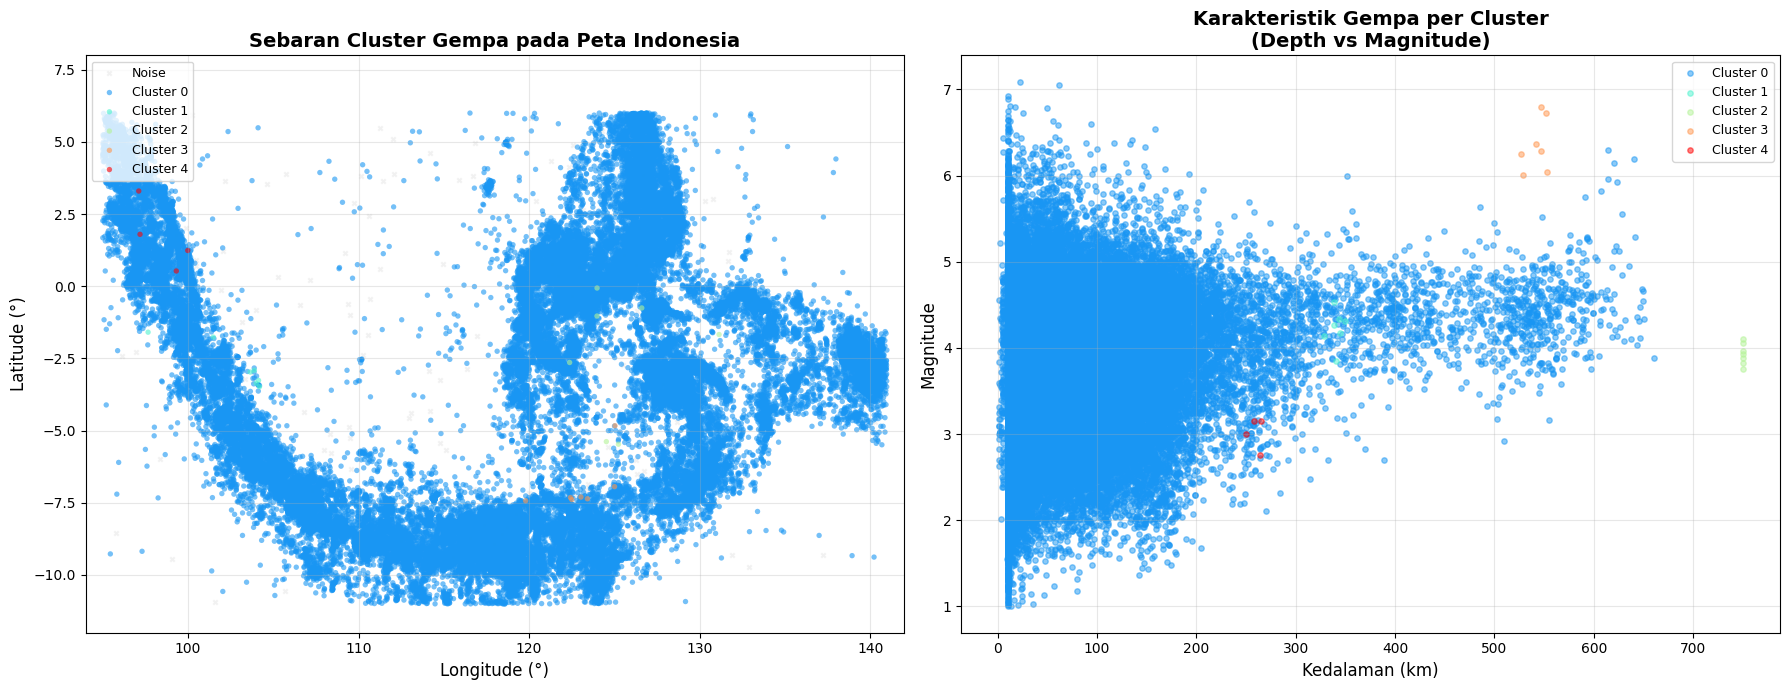

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.tab10(np.linspace(0, 1, max(n_clusters, 1)))
color_map = {-1: 'gray'}
for i in range(n_clusters):
    color_map[i] = colors[i]

for cluster_id in range(-1, n_clusters):
    mask = df_clean['Cluster'] == cluster_id
    if cluster_id == -1:
        axes[0].scatter(df_clean.loc[mask, 'longitude'], 
                       df_clean.loc[mask, 'latitude'],
                       c='gray', marker='x', s=10, alpha=0.3,
                       label=f'Noise ({sum(mask)})')
    else:
        axes[0].scatter(df_clean.loc[mask, 'longitude'], 
                       df_clean.loc[mask, 'latitude'],
                       c=[color_map[cluster_id]], marker='o', s=10, alpha=0.5,
                       label=f'Cluster {cluster_id} ({sum(mask)})')

axes[0].set_xlabel('Longitude', fontsize=11)
axes[0].set_ylabel('Latitude', fontsize=11)
axes[0].set_title('Sebaran Lokasi Gempa Berdasarkan Cluster', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, alpha=0.3)

for cluster_id in range(n_clusters):
    mask = df_clean['Cluster'] == cluster_id
    axes[1].scatter(df_clean.loc[mask, 'depth'], 
                   df_clean.loc[mask, 'magnitude'],
                   c=[color_map[cluster_id]], marker='o', s=15, alpha=0.5,
                   label=f'Cluster {cluster_id}')

axes[1].set_xlabel('Kedalaman (km)', fontsize=11)
axes[1].set_ylabel('Magnitudo', fontsize=11)
axes[1].set_title('Hubungan Kedalaman vs Magnitudo per Cluster', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()